# Escolaridade do candidato × escolaridade da população

> Grau de escolaridade do candidato × grau de escolaridade dos votadores; existe relação entre escolaridade do candidato e sua chance de ser eleito? Também, locais com menor escolaridade costumam eleger pessoas de semelhante escolaridade? **[2022, 2024]**

**Recorte:** AM, GO, MA, MT, RS e SE (os estados do grupo), eleições ordinárias de 2022 e 2024.

A pergunta tem três partes, e cada uma usa uma unidade de análise:

| Parte | Pergunta | Unidade | Medida |
|---|---|---|---|
| **A** | Candidatos e eleitos se parecem com a população? | grupo | distribuição nos 4 níveis |
| **B** | A escolaridade muda a chance de ser eleito? | candidato | taxa = eleitos ÷ candidatos, por grau e **por cargo** |
| **C** | Município menos escolarizado elege gente menos escolarizada? | município (2024) | moda + % com superior, população × eleitos |

**Fontes**

- Candidato: TSE `consulta_cand`, coluna `CD_GRAU_INSTRUCAO` (8 graus, autodeclarado no registro da candidatura).
- População: **Censo 2022, SIDRA 10061**, pessoas de 18 anos ou mais por nível de instrução (4 níveis). É a escolaridade medida pelo IBGE. Mede a população adulta, não o eleitorado; a diferença é pequena porque o voto é obrigatório dos 18 aos 70 anos.
- Ponte entre as duas escalas: tabela `GRAU_INSTRUCAO` (graus 1, 2, 3 → nível 1; 4, 5 → 2; 6, 7 → 3; 8 → 4).

**Pré-requisito:** banco carregado (ver o PR #29):

```bash
uv run python -m scripts.coleta.coleta_tse candidatos municipio_tse_ibge --uf AM,GO,MA,MT,RS,SE
uv run python -m scripts.coleta.coleta_ibge sidra
uv run python scripts/carregar_staging.py 00_modelo 06_carga_nucleo 10_q4
```

Este notebook só **lê** `dados/processed/tse.duckdb`; não toca nos CSVs. Todas as consultas estão em `sql/10_q4_escolaridade.sql`.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "dados").exists() else Path.cwd().parent
con = duckdb.connect(str(ROOT / "dados" / "processed" / "tse.duckdb"), read_only=True)
SAIDA = ROOT / "output" / "q4"
SAIDA.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_rows", 100)

# Cores: paleta de referência validada (skill dataviz). Os 4 níveis são uma escala
# ordenada, então usam UM tom (azul) do claro ao escuro — validada com --ordinal.
SUPERFICIE = "#fcfcfb"
TEXTO, TEXTO_2, GRADE = "#0b0b0b", "#52514e", "#e4e3df"
NIVEL_COR = {1: "#86b6ef", 2: "#3987e5", 3: "#1c5cab", 4: "#0d366b"}
SERIE = "#2a78d6"
NIVEL_NOME = {
    1: "Sem instrução / fund. incompleto",
    2: "Fund. completo / médio incompleto",
    3: "Médio completo / sup. incompleto",
    4: "Superior completo",
}
GRAU_NOME = {
    1: "1 Analfabeto",
    2: "2 Lê e escreve",
    3: "3 Fund. incompleto",
    4: "4 Fund. completo",
    5: "5 Médio incompleto",
    6: "6 Médio completo",
    7: "7 Superior incompleto",
    8: "8 Superior completo",
}

plt.rcParams.update(
    {
        "figure.facecolor": SUPERFICIE,
        "axes.facecolor": SUPERFICIE,
        "savefig.facecolor": SUPERFICIE,
        "axes.edgecolor": GRADE,
        "axes.labelcolor": TEXTO_2,
        "text.color": TEXTO,
        "xtick.color": TEXTO_2,
        "ytick.color": TEXTO_2,
        "axes.grid": True,
        "grid.color": GRADE,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "figure.dpi": 110,
        "ytick.major.size": 0,
        "xtick.major.size": 0,
    }
)


def sql(q):
    return con.sql(q).df()

## 0. A base está certa?

Antes de qualquer gráfico, as seis checagens de `sql/validacao/q4_escolaridade.sql`. Cada uma deve voltar vazia, salvo as exceções conhecidas anotadas no arquivo:

- **V4:** 9 municípios sem prefeito eleito na ordinária de 2024 (eleição anulada ou *sub judice*);
- **V5:** Boa Esperança do Norte (MT), criado depois do Censo 2022;
- **V7:** 17 municípios em que o arquivo do TSE (gerado em 06/10/2026) traz todos os candidatos a vereador com situação `#NULO`, sem resultado.

In [2]:
arquivo = ROOT / "sql" / "validacao" / "q4_escolaridade.sql"
# tira os comentários antes de separar as consultas por ";"
texto = "\n".join(
    linha for linha in arquivo.read_text(encoding="utf-8").splitlines() if not linha.lstrip().startswith("--")
)
resultado = []
for consulta in (c for c in texto.split(";") if "SELECT" in c):
    nome = consulta.split("'")[1]
    linhas = con.sql(consulta).fetchall()
    resultado.append({"checagem": nome, "linhas": len(linhas), "situação": "OK" if not linhas else "ver abaixo"})
    if linhas:
        display(pd.DataFrame(linhas).iloc[:, 1:])
pd.DataFrame(resultado)

,1,2,3
0,SE,Barra Dos Coqueiros,0
1,MA,Santana Do Maranhão,0
2,MA,Guimarães,0
3,SE,Cedro De São João,0
4,MA,Anajatuba,0
5,RS,Arroio Do Sal,0
6,SE,Nossa Senhora Do Socorro,0
7,GO,Iporá,0
8,GO,Americano Do Brasil,0


,1,2,3
0,MT,Boa Esperança Do Norte,0


,1,2,3
0,MA,São Benedito Do Rio Preto,1
1,GO,Jataí,1
2,GO,Valparaíso De Goiás,1
3,MA,Itapecuru Mirim,1
4,MA,Vitorino Freire,1
5,GO,Santo Antônio Do Descoberto,1
6,MA,Trizidela Do Vale,1
7,MA,São Luís Gonzaga Do Maranhão,1
8,GO,Buriti Alegre,1
9,GO,Cavalcante,1


,checagem,linhas,situação
0,V1 grau sem nível,0,OK
1,V2 soma da parte B,0,OK
2,V3 eleitos ≠ vagas,0,OK
3,V4 prefeitos eleitos ≠ 1,9,ver abaixo
4,V5 censo incompleto,1,ver abaixo
5,V6 perfil não soma 100,0,OK
6,V7 sem vereador eleito,17,ver abaixo


In [3]:
sql("""
    SELECT ano, sg_uf, count(*) AS candidaturas, count(*) FILTER (WHERE fl_eleito) AS eleitos
    FROM q4_candidatura GROUP BY ALL ORDER BY ano, sg_uf
""").pivot(index="sg_uf", columns="ano")

candidaturas        eleitos      
ano           2022   2024    2022  2024
sg_uf                                  
AM             592   7600      34   812
GO            1132  17490      60  2675
MA             885  15066      62  2549
MT             457  10427      34  1575
RS            1352  27239      88  5398
SE             481   5101      34   873

## A. Perfil: candidatos e eleitos se parecem com a população?

Três grupos na mesma escala de 4 níveis do Censo:

- **População 18+**: Censo 2022 (o mesmo retrato serve às duas eleições);
- **Candidatos**: quem foi a voto, sem vices e suplentes;
- **Eleitos**.

Consulta: `q4_perfil_uf`.

In [4]:
perfil = sql("SELECT ano, sg_uf, grupo, cd_nivel, qt FROM q4_perfil_uf")
ordem_grupos = ["População 18+ (Censo 2022)", "Candidatos", "Eleitos"]

# as 6 UFs juntas: soma as contagens antes de calcular o %
geral = perfil.groupby(["ano", "grupo", "cd_nivel"], as_index=False)["qt"].sum()
geral["pc"] = 100 * geral["qt"] / geral.groupby(["ano", "grupo"])["qt"].transform("sum")
tabela_a = geral.pivot_table(index=["ano", "grupo"], columns="cd_nivel", values="pc").round(1)
tabela_a.columns = [NIVEL_NOME[c] for c in tabela_a.columns]
tabela_a.reindex(ordem_grupos, level=1)

Sem instrução / fund. incompleto  \
ano  grupo                                                          
2022 População 18+ (Censo 2022)                              33.7   
     Candidatos                                               3.6   
     Eleitos                                                  1.0   
2024 População 18+ (Censo 2022)                              33.7   
     Candidatos                                              12.7   
     Eleitos                                                  9.4   

                                 Fund. completo / médio incompleto  \
ano  grupo                                                           
2022 População 18+ (Censo 2022)                               16.6   
     Candidatos                                                6.4   
     Eleitos                                                   1.9   
2024 População 18+ (Censo 2022)                               16.6   
     Candidatos                                               15.1   
     Eleitos                                                  12.4   

                                 Médio completo / sup. incompleto  \
ano  grupo                                                          
2022 População 18+ (Censo 2022)                              34.7   
     Candidatos                                              33.8   
     Eleitos                                                 17.9   
2024 População 18+ (Censo 2022)                              34.7   
     Candidatos                                              43.7   
     Eleitos                                                 41.2   

                                 Superior completo  
ano  grupo                                          
2022 População 18+ (Censo 2022)               15.0  
     Candidatos                               56.3  
     Eleitos                                  79.2  
2024 População 18+ (Censo 2022)               15.0  
     Candidatos                               28.5  
     Eleitos                                  37.0

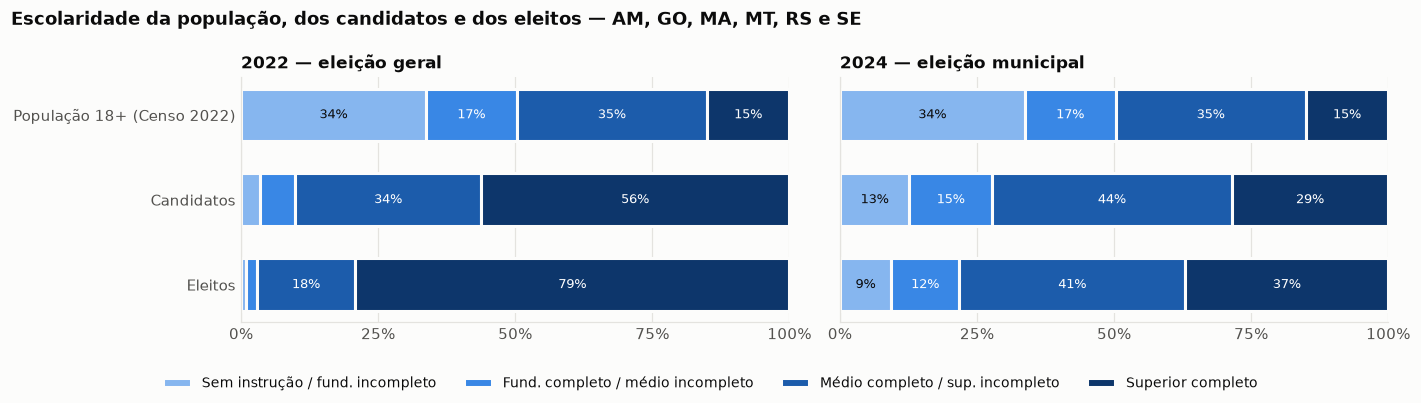

In [5]:
def barras_100(ax, dados, rotulos, titulo):
    """Barras horizontais 100% empilhadas: uma por grupo, um segmento por nível."""
    y = np.arange(len(rotulos))[::-1]
    esquerda = np.zeros(len(rotulos))
    for nivel in (1, 2, 3, 4):
        larg = np.array([dados.get((r, nivel), 0.0) for r in rotulos])
        ax.barh(
            y,
            larg,
            left=esquerda,
            height=0.62,
            color=NIVEL_COR[nivel],
            edgecolor=SUPERFICIE,
            linewidth=2,
            label=NIVEL_NOME[nivel],
        )
        for yi, li, ei in zip(y, larg, esquerda, strict=True):
            if li >= 7:  # rótulo só onde cabe
                cor_txt = TEXTO if nivel == 1 else "white"
                ax.text(ei + li / 2, yi, f"{li:.0f}%", ha="center", va="center", fontsize=8.5, color=cor_txt)
        esquerda += larg
    ax.set_yticks(y, rotulos)
    ax.set_xlim(0, 100)
    ax.set_xticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"])
    ax.grid(axis="y", visible=False)
    ax.set_title(titulo, loc="left")


fig, eixos = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, ano in zip(eixos, (2022, 2024), strict=True):
    d = geral[geral.ano == ano].set_index(["grupo", "cd_nivel"])["pc"].to_dict()
    barras_100(ax, d, ordem_grupos, f"{ano} — {'eleição geral' if ano == 2022 else 'eleição municipal'}")
fig.suptitle(
    "Escolaridade da população, dos candidatos e dos eleitos — AM, GO, MA, MT, RS e SE",
    x=0.01,
    ha="left",
    fontweight="bold",
)
fig.tight_layout(rect=(0, 0.1, 1, 1))
fig.legend(*eixos[0].get_legend_handles_labels(), loc="lower center", ncol=4, frameon=False, fontsize=9)
fig.savefig(SAIDA / "a_perfil_geral.png", bbox_inches="tight")
plt.show()

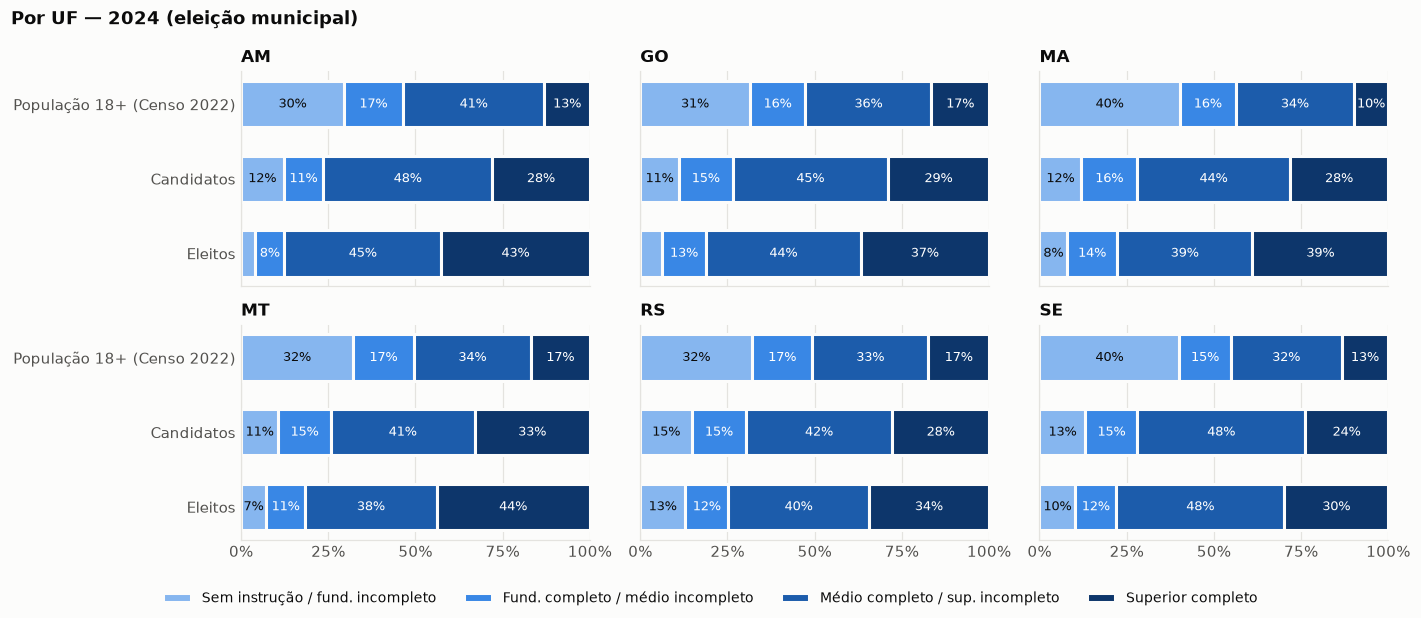

In [6]:
fig, eixos = plt.subplots(2, 3, figsize=(13, 5.6), sharex=True, sharey=True)
pc_uf = perfil.assign(pc=lambda d: 100 * d.qt / d.groupby(["ano", "sg_uf", "grupo"]).qt.transform("sum"))
for ax, uf in zip(eixos.flat, ["AM", "GO", "MA", "MT", "RS", "SE"], strict=True):
    d = pc_uf[(pc_uf.ano == 2024) & (pc_uf.sg_uf == uf)].set_index(["grupo", "cd_nivel"])["pc"].to_dict()
    barras_100(ax, d, ordem_grupos, uf)
fig.suptitle("Por UF — 2024 (eleição municipal)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.legend(*eixos[0, 0].get_legend_handles_labels(), loc="lower center", ncol=4, frameon=False, fontsize=9)
fig.savefig(SAIDA / "a_perfil_uf_2024.png", bbox_inches="tight")
plt.show()

**Como ler:** cada barra soma 100%. Compare o tamanho do segmento escuro (superior completo) e do mais claro (sem instrução / fundamental incompleto) entre a população e os eleitos.

**Cuidado:** em 2022 os candidatos disputam cargos estaduais e federais, e a comparação é com a população adulta do estado inteiro. Em 2024, com a do conjunto dos municípios.

## B. A escolaridade muda a chance de ser eleito?

Para cada grau de 1 a 8: quantos candidatos, quantos eleitos e a **taxa de eleição** = eleitos ÷ candidatos.

Por que a taxa, e não só "X eleitos têm superior completo"? Porque a contagem de eleitos depende de quantos candidatos daquele grau existem. Se 40% dos eleitos têm superior porque 40% dos candidatos têm superior, a escolaridade não mudou a chance de ninguém.

Sempre **por cargo**: vereador e deputado federal têm taxas de eleição muito diferentes, e misturar cargos muda o resultado.

Consulta: `q4_chance_por_grau`.

In [7]:
chance = sql("SELECT * FROM q4_chance_por_grau ORDER BY ano, ds_cargo, cd_grau_instrucao")
tabela_b = chance.pivot_table(
    index="cd_grau_instrucao", columns=["ano", "ds_cargo"], values=["qt_candidatos", "qt_eleitos", "pc_taxa_eleicao"]
)
tabela_b.index = [GRAU_NOME[g] for g in tabela_b.index]
tabela_b.swaplevel(0, 2, axis=1).sort_index(axis=1, level=[0, 1]).fillna("")

ds_cargo              DEPUTADO ESTADUAL                           \
ano                                2022                            
                        pc_taxa_eleicao qt_candidatos qt_eleitos   
1 Analfabeto                                                       
2 Lê e escreve                      0.0          30.0        0.0   
3 Fund. incompleto                  2.0          98.0        2.0   
4 Fund. completo                    1.3         152.0        2.0   
5 Médio incompleto                  2.6          76.0        2.0   
6 Médio completo                    2.7         783.0       21.0   
7 Superior incompleto               3.8         312.0       12.0   
8 Superior completo                10.3        1667.0      171.0   

ds_cargo              DEPUTADO FEDERAL                           \
ano                               2022                            
                       pc_taxa_eleicao qt_candidatos qt_eleitos   
1 Analfabeto                                                      
2 Lê e escreve                     0.0          21.0        0.0   
3 Fund. incompleto                 4.0          25.0        1.0   
4 Fund. completo                   1.8          56.0        1.0   
5 Médio incompleto                 4.0          25.0        1.0   
6 Médio completo                   2.3         386.0        9.0   
7 Superior incompleto              8.6         162.0       14.0   
8 Superior completo                6.3        1012.0       64.0   

ds_cargo                   GOVERNADOR                           \
ano                              2022                            
                      pc_taxa_eleicao qt_candidatos qt_eleitos   
1 Analfabeto                                                     
2 Lê e escreve                                                   
3 Fund. incompleto                                               
4 Fund. completo                                                 
5 Médio incompleto                                               
6 Médio completo                  0.0           4.0        0.0   
7 Superior incompleto             0.0           3.0        0.0   
8 Superior completo              14.3          42.0        6.0   

ds_cargo                     PREFEITO                           \
ano                              2024                            
                      pc_taxa_eleicao qt_candidatos qt_eleitos   
1 Analfabeto                                                     
2 Lê e escreve                    5.6          18.0        1.0   
3 Fund. incompleto               40.4         151.0       61.0   
4 Fund. completo                 44.9         138.0       62.0   
5 Médio incompleto               39.6          53.0       21.0   
6 Médio completo                 39.5         832.0      329.0   
7 Superior incompleto            36.8         185.0       68.0   
8 Superior completo              38.1        1804.0      688.0   

ds_cargo                      SENADOR                           \
ano                              2022                            
                      pc_taxa_eleicao qt_candidatos qt_eleitos   
1 Analfabeto                                                     
2 Lê e escreve                                                   
3 Fund. incompleto                                               
4 Fund. completo                  0.0           1.0        0.0   
5 Médio incompleto                0.0           2.0        0.0   
6 Médio completo                  0.0           4.0        0.0   
7 Superior incompleto             0.0           2.0        0.0   
8 Superior completo              16.7          36.0        6.0   

ds_cargo                     VEREADOR                           
ano                              2024                           
                      pc_taxa_eleicao qt_candidatos qt_eleitos  
1 Analfabeto                      0.0           2.0        0.0  
2 Lê e escreve                    6.7        1734.0      116.0  
3 Fund.

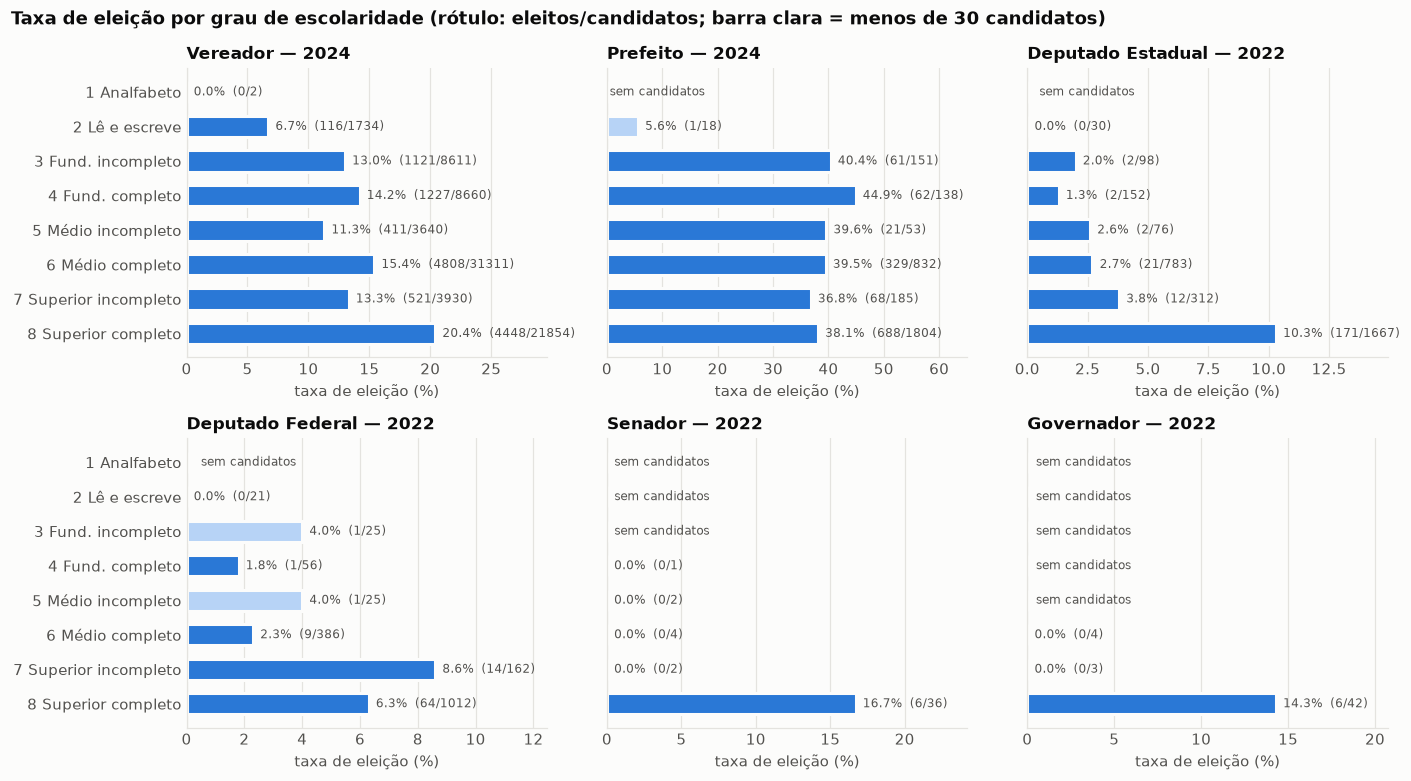

In [8]:
PAINEIS = [
    (2024, "VEREADOR"),
    (2024, "PREFEITO"),
    (2022, "DEPUTADO ESTADUAL"),
    (2022, "DEPUTADO FEDERAL"),
    (2022, "SENADOR"),
    (2022, "GOVERNADOR"),
]
N_MINIMO = 30  # abaixo disso a taxa é instável: barra clara e o n escrito

fig, eixos = plt.subplots(2, 3, figsize=(13, 7.2), sharey=True)
for ax, (ano, cargo) in zip(eixos.flat, PAINEIS, strict=True):
    d = chance[(chance.ano == ano) & (chance.ds_cargo == cargo)].set_index("cd_grau_instrucao")
    graus = list(range(1, 9))
    y = np.arange(8)[::-1]
    taxa = [d.pc_taxa_eleicao.get(g, np.nan) for g in graus]
    n = [int(d.qt_candidatos.get(g, 0)) for g in graus]
    cores = [SERIE if ni >= N_MINIMO else "#b7d3f6" for ni in n]
    ax.barh(y, np.nan_to_num(taxa), height=0.62, color=cores, edgecolor=SUPERFICIE, linewidth=2)
    limite = max(np.nanmax(taxa) * 1.45, 5)
    for yi, ti, ni, g in zip(y, taxa, n, graus, strict=True):
        if ni == 0:
            ax.text(0.5, yi, "sem candidatos", va="center", fontsize=8, color=TEXTO_2)
        else:
            eleitos = int(d.qt_eleitos.get(g, 0))
            ax.text(ti + limite * 0.02, yi, f"{ti:.1f}%  ({eleitos}/{ni})", va="center", fontsize=8, color=TEXTO_2)
    ax.set_xlim(0, limite)
    ax.set_yticks(y, [GRAU_NOME[g] for g in graus])
    ax.grid(axis="y", visible=False)
    ax.set_title(f"{cargo.title()} — {ano}", loc="left")
    ax.set_xlabel("taxa de eleição (%)")
fig.suptitle(
    f"Taxa de eleição por grau de escolaridade (rótulo: eleitos/candidatos; barra clara = menos de {N_MINIMO} candidatos)",
    x=0.01,
    ha="left",
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(SAIDA / "b_chance_por_grau.png", bbox_inches="tight")
plt.show()

**Como ler:** compare as barras **dentro de cada painel**; entre painéis, a escala muda. Barras claras têm poucos candidatos, e uma eleição a mais ou a menos muda muito a taxa.

**O que este gráfico não mostra:** que a escolaridade *causa* a vitória. Escolaridade anda junto com dinheiro de campanha, partido e estar no mandato (reeleição). O gráfico mostra **associação**.

In [9]:
# Teste de independência (qui-quadrado) entre grau e resultado, por cargo.
# H0: a taxa de eleição é a mesma em todos os graus. Graus com menos de 5 eleitos
# esperados distorcem o teste, então juntamos os graus 1-3 (nível "sem instrução /
# fundamental incompleto") quando necessário — mesma regra para todos os cargos.
from math import exp, lgamma, log


def qui2_pvalor(qui2, gl):
    """P(X >= qui2), X ~ qui-quadrado(gl). Série quando x < a+1, fração contínua (Lentz) na cauda."""
    a, x = gl / 2, qui2 / 2
    if x <= 0:
        return 1.0
    fator = exp(-x + a * log(x) - lgamma(a))
    if x < a + 1:  # série da gama incompleta inferior: P(a, x)
        termo = soma = 1 / a
        k = 0
        while abs(termo) > abs(soma) * 1e-15:
            k += 1
            termo *= x / (a + k)
            soma += termo
        return 1 - fator * soma
    # cauda superior Q(a, x) direto, sem subtrair de 1 (não perde precisão)
    tiny = 1e-300
    b = x + 1 - a
    c, d = 1 / tiny, 1 / b
    h = d
    for i in range(1, 500):
        an = -i * (i - a)
        b += 2
        d = an * d + b
        d = tiny if abs(d) < tiny else d
        c = b + an / c
        c = tiny if abs(c) < tiny else c
        d = 1 / d
        delta = d * c
        h *= delta
        if abs(delta - 1) < 1e-15:
            break
    return fator * h


linhas = []
for (ano, cargo), d in chance.groupby(["ano", "ds_cargo"]):
    d = d.assign(faixa=d.cd_grau_instrucao.map(lambda g: "1-3" if g <= 3 else str(g)))
    t = d.groupby("faixa")[["qt_eleitos", "qt_candidatos"]].sum()
    obs = np.column_stack([t.qt_eleitos, t.qt_candidatos - t.qt_eleitos])
    esp = obs.sum(1, keepdims=True) * obs.sum(0, keepdims=True) / obs.sum()
    qui2 = float(((obs - esp) ** 2 / esp).sum())
    gl = obs.shape[0] - 1
    linhas.append(
        {
            "ano": ano,
            "cargo": cargo,
            "candidatos": int(obs.sum()),
            "qui²": round(qui2, 1),
            "gl": gl,
            "p-valor": qui2_pvalor(qui2, gl),
            "menor esperado": round(float(esp.min()), 1),
        }
    )
teste = pd.DataFrame(linhas)
teste["conclusão (5%)"] = np.where(teste["p-valor"] < 0.05, "taxa varia com o grau", "sem evidência de diferença")
teste.style.format({"p-valor": lambda p: "< 1e-100" if p == 0 else f"{p:.2g}"})

,ano,cargo,candidatos,qui²,gl,p-valor,menor esperado,conclusão (5%)
0,2022,DEPUTADO ESTADUAL,3118,72.200000,5,3.6e-14,5.100000,taxa varia com o grau
1,2022,DEPUTADO FEDERAL,1687,14.800000,5,0.011,1.300000,taxa varia com o grau
2,2022,GOVERNADOR,49,1.100000,2,0.57,0.400000,sem evidência de diferença
3,2022,SENADOR,45,1.700000,4,0.79,0.100000,sem evidência de diferença
4,2024,PREFEITO,3181,3.300000,5,0.65,20.500000,sem evidência de diferença
5,2024,VEREADOR,79742,550.100000,5,1.2e-116,577.500000,taxa varia com o grau


**Como ler o teste:** p-valor abaixo de 0,05 indica que a taxa de eleição **não** é a mesma em todos os graus daquele cargo. Quando a coluna "menor esperado" fica abaixo de 5 (governador e senador, com poucos candidatos), o teste é pouco confiável: vale o gráfico, com cautela.

## C. Locais: município menos escolarizado elege gente menos escolarizada?

Só **2024**, porque é a eleição em que os eleitos são do município (prefeito e vereadores). Em 2022 os eleitos são estaduais e federais.

Duas medidas, por município:

1. **Moda**: o nível mais frequente na população e entre os eleitos. Boa para uma frase ("aqui predomina X, e os eleitos são em maioria Y"), fraca para comparar municípios, porque com 4 níveis ela se repete muito.
2. **% com superior completo**: na população × entre os eleitos. É contínua, então permite ver se *mais* escolaridade no município acompanha *mais* escolaridade entre os eleitos.

Consultas: `q4_municipio_nivel` e `q4_municipio`.

In [10]:
mun = sql("SELECT * FROM q4_municipio WHERE qt_vereadores_eleitos > 0 AND pc_populacao_superior IS NOT NULL")
total = sql("SELECT count(*) n FROM q4_municipio").n[0]
print(
    f"{len(mun)} de {total} municípios entram na parte C. Ficam fora os que não têm Censo "
    "(Boa Esperança do Norte/MT, V5) e os 17 em que o arquivo do TSE não traz resultado de vereador (V7)."
)

# Moda: quantos municípios em cada combinação (população × eleitos)
ordem = [NIVEL_NOME[i] for i in (1, 2, 3, 4)]
moda = pd.crosstab(mun.ds_moda_populacao, mun.ds_moda_eleitos, margins=True, margins_name="Total")
moda = moda.reindex(
    index=[o for o in ordem if o in moda.index] + ["Total"], columns=[o for o in ordem if o in moda.columns] + ["Total"]
)
moda.index.name, moda.columns.name = "moda da população ↓", "moda dos eleitos →"
moda.fillna(0).astype(int)

1221 de 1239 municípios entram na parte C. Ficam fora os que não têm Censo (Boa Esperança do Norte/MT, V5) e os 17 em que o arquivo do TSE não traz resultado de vereador (V7).


moda dos eleitos →,Superior completo,Total
moda da população ↓,,
Total,398,1221


In [11]:
print(f"Empates na moda dos eleitos (resolvidos para o nível menor): {int(mun.fl_empate_eleitos.sum())} municípios")
exemplos = mun.sort_values("pc_populacao_superior").iloc[[0, len(mun) // 2, -1]]
for _, m in exemplos.iterrows():
    print(
        f"- {m.nm_municipio} ({m.sg_uf}): na população predomina '{m.ds_moda_populacao.lower()}' "
        f"({m.pc_populacao_superior:.0f}% com superior); entre os {int(m.qt_eleitos)} eleitos, "
        f"'{m.ds_moda_eleitos.lower()}' ({m.pc_eleitos_superior:.0f}% com superior)."
    )

Empates na moda dos eleitos (resolvidos para o nível menor): 168 municípios
- Palmeirândia (MA): na população predomina 'sem instrução e fundamental incompleto' (2% com superior); entre os 12 eleitos, 'fundamental completo e médio incompleto' (33% com superior).
- São Nicolau (RS): na população predomina 'sem instrução e fundamental incompleto' (10% com superior); entre os 10 eleitos, 'sem instrução e fundamental incompleto' (10% com superior).
- Porto Alegre (RS): na população predomina 'médio completo e superior incompleto' (32% com superior); entre os 36 eleitos, 'superior completo' (83% com superior).


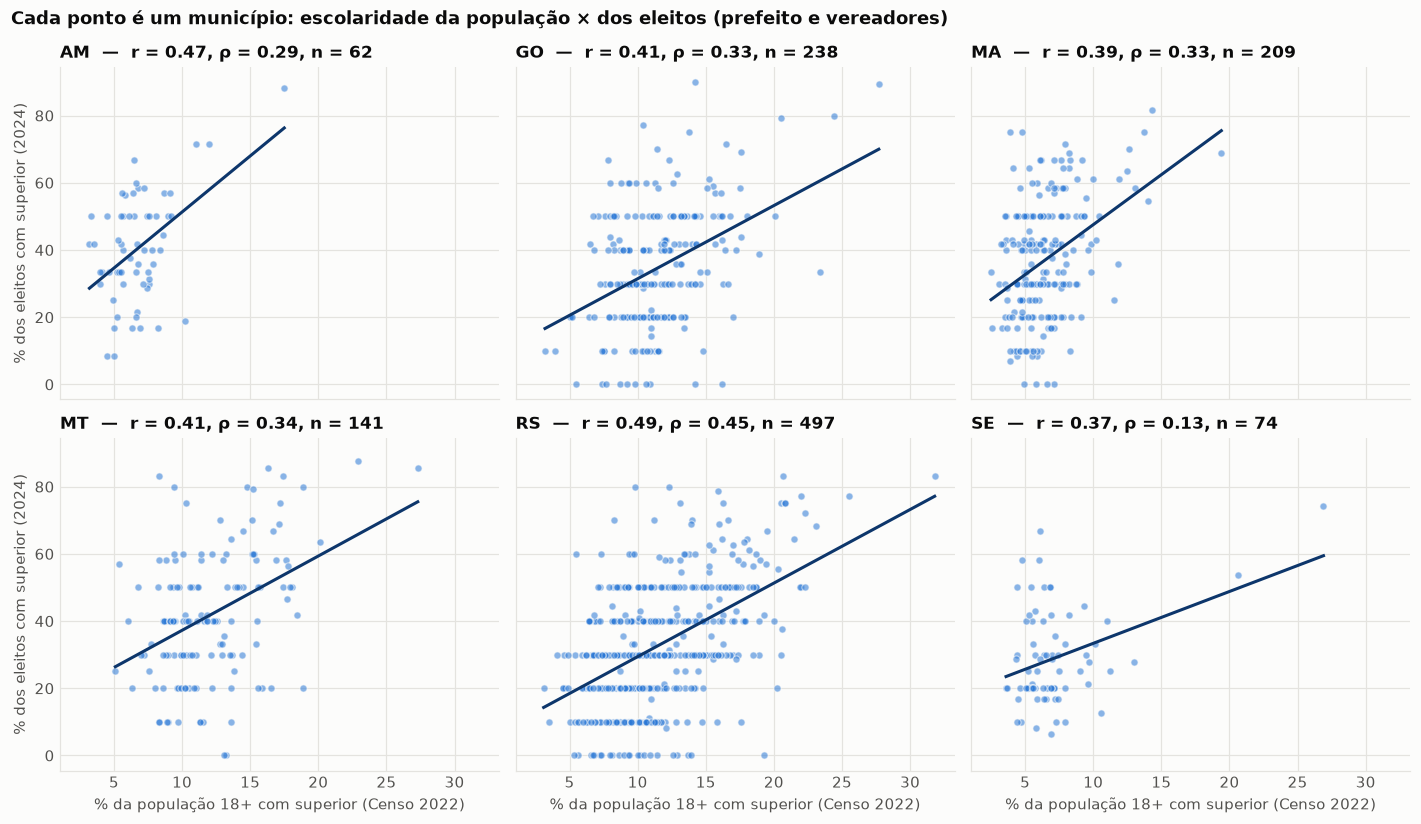

,UF,municípios,Pearson r,Spearman ρ,inclinação (p.p. por p.p.)
0,AM,62,0.47,0.29,3.34
1,GO,238,0.41,0.33,2.18
2,MA,209,0.39,0.33,2.98
3,MT,141,0.41,0.34,2.21
4,RS,497,0.49,0.45,2.19
5,SE,74,0.37,0.13,1.54


In [12]:
fig, eixos = plt.subplots(2, 3, figsize=(13, 7.6), sharex=True, sharey=True)
resumo = []
for ax, uf in zip(eixos.flat, ["AM", "GO", "MA", "MT", "RS", "SE"], strict=True):
    d = mun[mun.sg_uf == uf]
    x, y = d.pc_populacao_superior, d.pc_eleitos_superior
    ax.scatter(x, y, s=22, color=SERIE, alpha=0.55, edgecolor=SUPERFICIE, linewidth=0.8)
    a, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, a * xs + b, color="#0d366b", linewidth=2)
    r, rho = x.corr(y), x.rank().corr(y.rank())  # Spearman = Pearson dos postos
    resumo.append(
        {
            "UF": uf,
            "municípios": len(d),
            "Pearson r": round(r, 2),
            "Spearman ρ": round(rho, 2),
            "inclinação (p.p. por p.p.)": round(a, 2),
        }
    )
    ax.set_title(f"{uf}  —  r = {r:.2f}, ρ = {rho:.2f}, n = {len(d)}", loc="left")
for ax in eixos[1]:
    ax.set_xlabel("% da população 18+ com superior (Censo 2022)")
for ax in eixos[:, 0]:
    ax.set_ylabel("% dos eleitos com superior (2024)")
fig.suptitle(
    "Cada ponto é um município: escolaridade da população × dos eleitos (prefeito e vereadores)",
    x=0.01,
    ha="left",
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(SAIDA / "c_dispersao_uf.png", bbox_inches="tight")
plt.show()
pd.DataFrame(resumo)

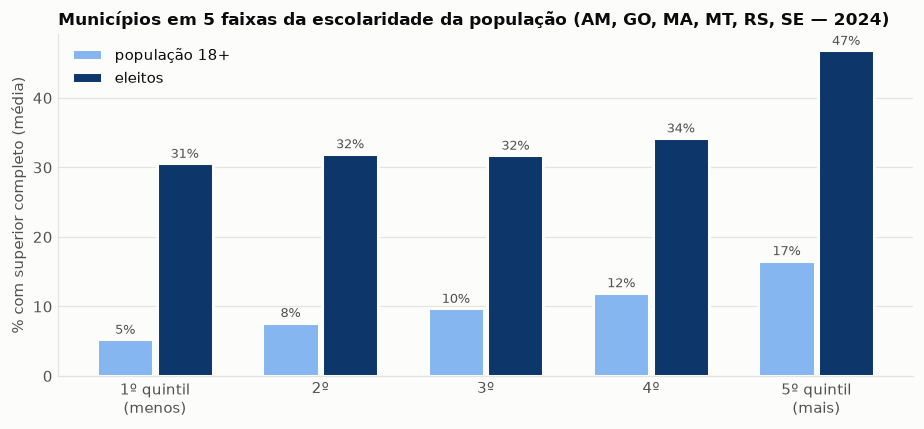

,pop,eleitos,n
faixa,,,
1º quintil\n(menos),5.3,30.6,253
2º,7.7,32.0,245
3º,9.7,31.7,241
4º,12.0,34.2,245
5º quintil\n(mais),16.6,46.8,237


In [13]:
# Versão para a apresentação: municípios das 6 UFs em 5 faixas (quintis) do %
# da população com superior; em cada faixa, a média do % dos eleitos com superior.
mun["faixa"] = pd.qcut(
    mun.pc_populacao_superior, 5, labels=["1º quintil\n(menos)", "2º", "3º", "4º", "5º quintil\n(mais)"]
)
q = mun.groupby("faixa", observed=True).agg(
    pop=("pc_populacao_superior", "mean"), eleitos=("pc_eleitos_superior", "mean"), n=("cod_ibge", "size")
)

fig, ax = plt.subplots(figsize=(8.5, 4))
xq = np.arange(len(q))
ax.bar(xq - 0.18, q["pop"], width=0.34, color=NIVEL_COR[1], edgecolor=SUPERFICIE, linewidth=2, label="população 18+")
ax.bar(xq + 0.18, q["eleitos"], width=0.34, color=NIVEL_COR[4], edgecolor=SUPERFICIE, linewidth=2, label="eleitos")
for xi, (p, e) in zip(xq, q[["pop", "eleitos"]].to_numpy(), strict=True):
    ax.text(xi - 0.18, p + 0.8, f"{p:.0f}%", ha="center", fontsize=8.5, color=TEXTO_2)
    ax.text(xi + 0.18, e + 0.8, f"{e:.0f}%", ha="center", fontsize=8.5, color=TEXTO_2)
ax.set_xticks(xq, q.index)
ax.set_ylabel("% com superior completo (média)")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper left")
ax.set_title("Municípios em 5 faixas da escolaridade da população (AM, GO, MA, MT, RS, SE — 2024)", loc="left")
fig.tight_layout()
fig.savefig(SAIDA / "c_quintis.png", bbox_inches="tight")
plt.show()
q.round(1)

**Como ler:** se "menos escolaridade elege menos escolaridade", os pontos sobem da esquerda para a direita (correlação positiva) e as barras escuras crescem do 1º para o 5º quintil.

**O que esta parte não pode concluir (falácia ecológica):** a comparação é entre **municípios**. Se municípios menos escolarizados elegem pessoas menos escolarizadas, isso **não** prova que o *eleitor* pouco escolarizado vota no candidato pouco escolarizado. Não há dado de em quem cada eleitor votou.

**Outros limites:**

- Município pequeno elege 9 a 11 pessoas, então o % dos eleitos pula de 10 em 10 pontos. Os pontos com poucos eleitos são ruidosos.
- O Censo é de 2022 e a eleição de 2024: dois anos de defasagem.
- 9 municípios ficaram sem prefeito eleito na eleição ordinária (V4); os vereadores deles continuam na análise.
- 17 municípios ficam fora da parte C porque o arquivo não traz o resultado de vereador (V7). Os 1.854 candidatos a vereador deles também não entram nas partes A e B.

## Ressalvas gerais (para a apresentação)

1. **Cargo é o principal confusor.** Toda comparação de chance é dentro do cargo.
2. **Correlação não é causa.** Escolaridade anda junto com dinheiro, partido e mandato atual.
3. **Falácia ecológica** na parte C: a conclusão vale para municípios, não para pessoas.
4. **Escalas diferentes:** o candidato tem 8 graus e o Censo 4 níveis. A ponte é a tabela `GRAU_INSTRUCAO`; a única escolha não óbvia é "lê e escreve" ir para o nível 1.
5. **Autodeclaração:** a escolaridade do candidato é a que ele declarou no registro da candidatura; a da população é medida pelo Censo.
6. **Fora da análise:** presidente (eleição nacional), vices e suplentes (herdam o resultado da chapa), candidaturas que não foram a voto e grau não informado (0 e -4).

Gráficos salvos em `output/q4/`.

In [14]:
con.close()